Table of contents:
1. Load Data
2. Preprocessing

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
!pip install scikeras

# 1. Load Data

In [6]:
df = pd.read_csv('/content/drive/MyDrive/Khóa luận tốt nghiệp/Data/Bondora_preprocessed_outliers_replaced.csv')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77394 entries, 0 to 77393
Data columns (total 38 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   BidsPortfolioManager                    77394 non-null  float64
 1   BidsApi                                 77394 non-null  float64
 2   BidsManual                              77394 non-null  float64
 3   UserName                                77394 non-null  object 
 4   NewCreditCustomer                       77394 non-null  int64  
 5   LoanDate                                77394 non-null  object 
 6   Age                                     77394 non-null  int64  
 7   Gender                                  77349 non-null  float64
 8   AppliedAmount                           77394 non-null  float64
 9   Amount                                  77394 non-null  float64
 10  Interest                                77394 non-null  fl

# 2. Data Preprocessing

In [8]:
df['Rating'].unique()

array([nan, 'F', 'C', 'HR', 'E', 'D', 'A', 'B', 'AA'], dtype=object)

In [9]:
df['Rating'].isna().sum()

np.int64(2728)

In [10]:
df.head()

,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,LoanDate,Age,Gender,AppliedAmount,Amount,...,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,Default,MaturityDifference,LastMaturity_LastPaymentOn,LastMaturity_FirstPaymentDate,LoanYear,LoanMonth,LoanDay
0,0.0,0.0,115.0410,KARU,1,2009-06-16,61,1.0,319.5582,115.0408,...,1.0,83.0852,0.0,0,0.0,-11.0,333.0,2009,6,16
1,0.0,0.0,140.6057,koort681,0,2009-06-15,48,1.0,191.7349,140.6057,...,2.0,255.6467,0.0,0,0.0,8.0,0.0,2009,6,15
2,0.0,0.0,319.5580,0ie,1,2009-06-15,58,1.0,319.5582,319.5409,...,0.0,0.0000,0.0,1,-1173.0,589.0,1751.0,2009,6,15
3,0.0,0.0,57.5205,Alyona,1,2009-06-15,23,1.0,127.8233,57.5205,...,1.0,134.2144,0.0,0,0.0,0.0,427.0,2009,6,15
4,0.0,0.0,319.5582,Kai,1,2009-06-14,25,1.0,319.5582,319.5436,...,1.0,146.9966,0.0,0,0.0,-1847.0,333.0,2009,6,14


In [11]:
df['Rating'].value_counts()

,count
Rating,
F,15657
HR,13151
E,12288
D,11772
C,10420
B,6926
A,2819
AA,1633


Encoding

In [12]:
rating_mapping = {'AA': 7, 'A': 6, 'B': 5, 'C': 4, 'D': 3, 'E': 2, 'F': 1}
df['Rating_Encoded'] = df['Rating'].map(rating_mapping)
print(df[['Rating', 'Rating_Encoded']].head())

  Rating  Rating_Encoded
0    NaN             NaN
1    NaN             NaN
2    NaN             NaN
3    NaN             NaN
4    NaN             NaN


In [13]:
df['Rating_Encoded'].replace(np.nan, 1, inplace=True)

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




In [14]:
df['Rating_Encoded'].head()
df.drop('Rating', axis=1, inplace=True)

In [15]:
df[['MonthlyPayment','Education' , 'EmploymentStatus','FreeCash']]

,MonthlyPayment,Education,EmploymentStatus,FreeCash
0,NaN,3.0,3.0,0.00
1,NaN,5.0,3.0,0.00
2,NaN,4.0,3.0,0.00
3,NaN,2.0,NaN,0.00
4,NaN,4.0,3.0,0.00
...,...,...,...,...
77389,107.68,3.0,3.0,792.32
77390,85.33,3.0,3.0,520.67
77391,80.42,3.0,5.0,1069.58
77392,84.51,5.0,3.0,50.49


Thay nan

In [16]:
df['MonthlyPayment'].replace(np.nan, df['MonthlyPayment'].median(), inplace=True)
df['Education'].replace(np.nan, df['Education'].median(), inplace=True)
df['EmploymentStatus'].replace(np.nan, df['EmploymentStatus'].median(), inplace=True)
df['FreeCash'].replace(np.nan, df['FreeCash'].median(), inplace=True)
df['Gender'].replace(np.nan, df['Gender'].median(), inplace=True)
df['DebtToIncome'].replace(np.nan, df['DebtToIncome'].median(), inplace=True)

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


A valu

In [17]:
df.isna().sum()

,0
BidsPortfolioManager,0
BidsApi,0
BidsManual,0
UserName,0
NewCreditCustomer,0
LoanDate,0
Age,0
Gender,0
AppliedAmount,0
Amount,0


In [18]:
df['UserName'].nunique()

44258

In [19]:
print(df['NewCreditCustomer'].value_counts())

NewCreditCustomer
1    48867
0    28527
Name: count, dtype: int64


In [20]:
df['Age'] = df['Age'].astype('bool')

In [21]:
df = df.sort_values(by=['LoanDate'])

In [22]:
# Display or use the updated DataFrame 'df'
df = df.drop(columns=['PrincipalPaymentsMade',
    'InterestAndPenaltyPaymentsMade',
    'PrincipalBalance',
    'InterestAndPenaltyBalance'])

df['LoanDate'] = pd.to_datetime(df['LoanDate'])

df['Dayssincepreviousloan'] = df.groupby('UserName')['LoanDate'].diff().dt.days
df['Dayssincepreviousloan'] = df['Dayssincepreviousloan'].fillna(-1)
df['Dayssincepreviousloan'] = df['Dayssincepreviousloan'].astype(int)

df = df.drop(columns=['LoanYear', 'LoanMonth','LoanDay'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 77394 entries, 193 to 76824
Data columns (total 32 columns):
 #   Column                                  Non-Null Count  Dtype         
---  ------                                  --------------  -----         
 0   BidsPortfolioManager                    77394 non-null  float64       
 1   BidsApi                                 77394 non-null  float64       
 2   BidsManual                              77394 non-null  float64       
 3   UserName                                77394 non-null  object        
 4   NewCreditCustomer                       77394 non-null  int64         
 5   LoanDate                                77394 non-null  datetime64[ns]
 6   Age                                     77394 non-null  bool          
 7   Gender                                  77394 non-null  float64       
 8   AppliedAmount                           77394 non-null  float64       
 9   Amount                                  77394 non-nul

In [23]:
from sklearn.model_selection import GroupShuffleSplit


def train_test_split_grouped(df, group_col='UserName', test_size=0.2, random_state=42):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    train_idx, test_idx = next(splitter.split(df, groups=df[group_col]))

    df_train = df.iloc[train_idx].reset_index(drop=True)
    df_test = df.iloc[test_idx].reset_index(drop=True)

    return df_train, df_test

# Chia tập train/test
df_train, df_test = train_test_split_grouped(df, group_col='UserName')

# Kiểm tra số lượng mẫu trong mỗi tập
print(f"Train size: {len(df_train)}, Test size: {len(df_test)}")

# Kiểm tra xem có khách hàng nào bị chia giữa train và test không
common_customers = set(df_train['UserName']).intersection(set(df_test['UserName']))
assert len(common_customers) == 0, "Có khách hàng bị chia giữa train và test!"


Train size: 61811, Test size: 15583


In [24]:
df_train = df_train.sort_values(by=['UserName','LoanDate'])
df_test = df_test.sort_values(by=['UserName','LoanDate'])
X_train = df_train.drop(columns=['Default'])
y_train = df_train['Default']
X_test = df_test.drop(columns=['Default'])
y_test = df_test['Default']

In [25]:
X_train.columns

Index(['BidsPortfolioManager', 'BidsApi', 'BidsManual', 'UserName',
       'NewCreditCustomer', 'LoanDate', 'Age', 'Gender', 'AppliedAmount',
       'Amount', 'Interest', 'LoanDuration', 'MonthlyPayment', 'Education',
       'EmploymentStatus', 'IncomeTotal', 'ExistingLiabilities',
       'LiabilitiesTotal', 'RefinanceLiabilities', 'DebtToIncome', 'FreeCash',
       'MonthlyPaymentDay', 'Restructured', 'NoOfPreviousLoansBeforeLoan',
       'AmountOfPreviousLoansBeforeLoan',
       'PreviousEarlyRepaymentsCountBeforeLoan', 'MaturityDifference',
       'LastMaturity_LastPaymentOn', 'LastMaturity_FirstPaymentDate',
       'Rating_Encoded', 'Dayssincepreviousloan'],
      dtype='object')

In [26]:
# train = df[df['LoanDate']<'01-01-2019']
# test = df[df['LoanDate']>='01-01-2019']
# train = train.sort_values(by=['LoanDate'])
# test = test.sort_values(by=['LoanDate'])

# train = train.drop(columns=['LoanDate'])
# test = test.drop(columns=['LoanDate'])

In [27]:
# train['Default'].value_counts()

In [28]:
# test['Default'].value_counts()

In [29]:
# X_train = train.drop(columns=['Default'])
# y_train = train['Default']
# X_test = test.drop(columns=['Default'])
# y_test = test['Default']

In [30]:
X_train.shape

(61811, 31)

In [31]:
X_train.columns

Index(['BidsPortfolioManager', 'BidsApi', 'BidsManual', 'UserName',
       'NewCreditCustomer', 'LoanDate', 'Age', 'Gender', 'AppliedAmount',
       'Amount', 'Interest', 'LoanDuration', 'MonthlyPayment', 'Education',
       'EmploymentStatus', 'IncomeTotal', 'ExistingLiabilities',
       'LiabilitiesTotal', 'RefinanceLiabilities', 'DebtToIncome', 'FreeCash',
       'MonthlyPaymentDay', 'Restructured', 'NoOfPreviousLoansBeforeLoan',
       'AmountOfPreviousLoansBeforeLoan',
       'PreviousEarlyRepaymentsCountBeforeLoan', 'MaturityDifference',
       'LastMaturity_LastPaymentOn', 'LastMaturity_FirstPaymentDate',
       'Rating_Encoded', 'Dayssincepreviousloan'],
      dtype='object')

In [32]:
X_train = X_train.drop(columns=['LoanDate'])
X_test = X_test.drop(columns=['LoanDate'])

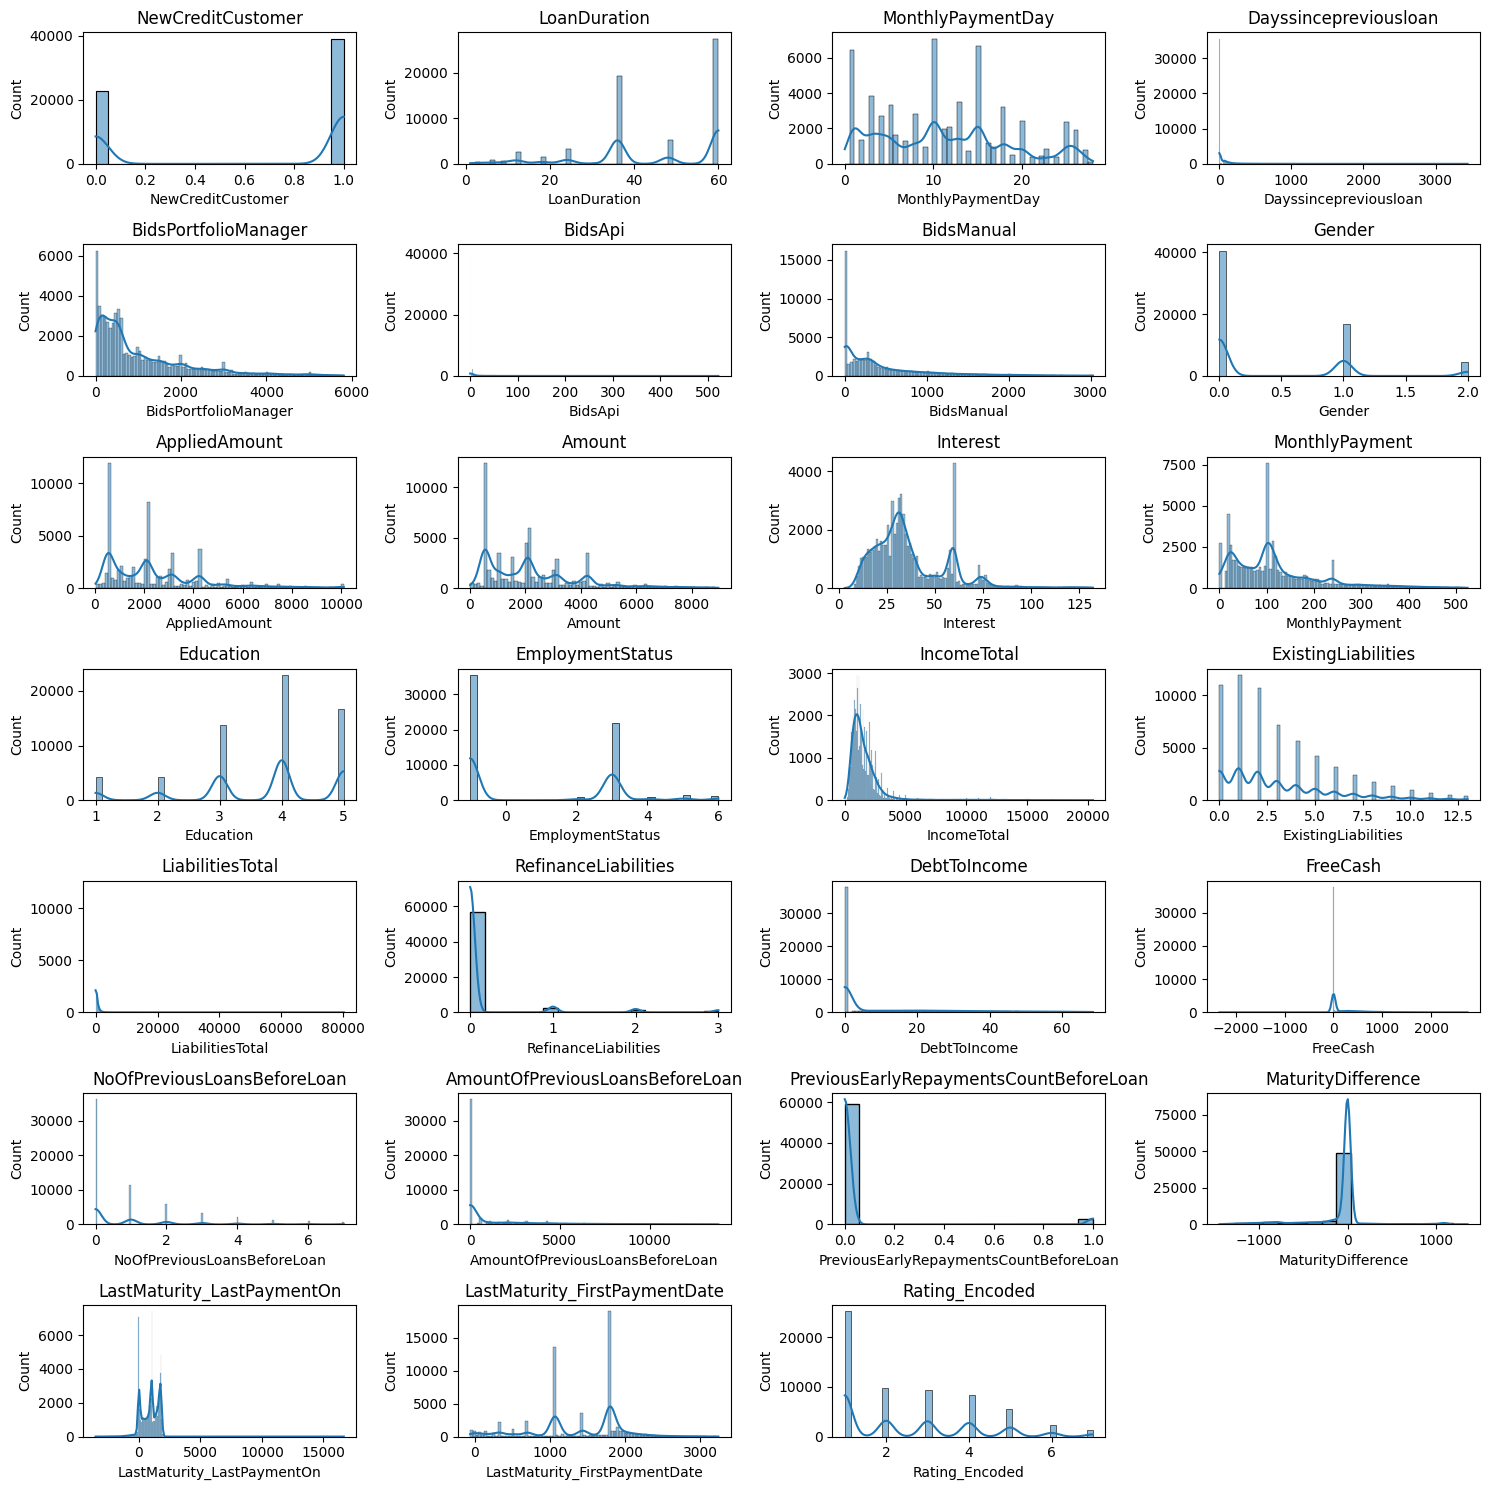

In [33]:
import matplotlib.pyplot as plt
def visualize_dis():
  int64_features = X_train.select_dtypes(include='int64').columns
  float64_features = X_train.select_dtypes(include='float64').columns

  num_plots = len(int64_features) + len(float64_features)
  cols = 4  # Adjust number of columns as needed
  rows = (num_plots + cols - 1) // cols

  fig, axes = plt.subplots(rows, cols, figsize=(15, 15))
  axes = axes.flatten()

  for i, feature in enumerate(int64_features):
      sns.histplot(X_train[feature], ax=axes[i], kde=True)
      axes[i].set_title(feature)

  for i, feature in enumerate(float64_features):
      sns.histplot(X_train[feature], ax=axes[i + len(int64_features)], kde=True)
      axes[i + len(int64_features)].set_title(feature)

  for j in range(i + len(int64_features) + 1, len(axes)):
    axes[j].set_visible(False) # Hide any unused subplots

  plt.tight_layout()
  plt.show()
visualize_dis()

In [34]:
numeric_features_train_df = X_train.select_dtypes(include=['int64','float64','bool'])
numeric_features = numeric_features_train_df.columns

In [35]:
X_train.head()

,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,Age,Gender,AppliedAmount,Amount,Interest,...,MonthlyPaymentDay,Restructured,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,MaturityDifference,LastMaturity_LastPaymentOn,LastMaturity_FirstPaymentDate,Rating_Encoded,Dayssincepreviousloan
4100,495.0,0.0,205.0000,-inline-,1,True,0.0,700.0000,700.0000,28.00,...,7,False,0.0,0.0000,0.0,0.0,27.0,515.0,3.0,-1
249,0.0,0.0,319.5581,-kiisuke-,1,True,1.0,319.5582,319.5587,30.00,...,5,False,0.0,0.0000,0.0,0.0,0.0,336.0,1.0,-1
849,0.0,0.0,255.6466,-kiisuke-,0,True,1.0,255.6466,255.6929,38.00,...,5,False,1.0,319.5587,0.0,0.0,266.0,518.0,1.0,219
908,0.0,0.0,236.4732,-kiisuke-,0,True,1.0,236.4731,236.4165,38.00,...,5,False,2.0,575.2516,0.0,0.0,299.0,518.0,1.0,15
11999,0.0,0.0,1000.0000,-party-power-,1,True,0.0,1000.0000,1000.0000,41.81,...,10,False,0.0,0.0000,0.0,0.0,118.0,335.0,1.0,-1


In [36]:
features_to_transform = ['BidsPortfolioManager', 'BidsApi', 'BidsManual',
       'AppliedAmount', 'Amount',
       'Interest', 'LoanDuration', 'MonthlyPayment', 'Education',
       'EmploymentStatus', 'IncomeTotal', 'ExistingLiabilities',
       'LiabilitiesTotal', 'RefinanceLiabilities', 'DebtToIncome', 'FreeCash',
       'MonthlyPaymentDay', 'NoOfPreviousLoansBeforeLoan',
       'AmountOfPreviousLoansBeforeLoan',
       'PreviousEarlyRepaymentsCountBeforeLoan', 'MaturityDifference',
       'LastMaturity_LastPaymentOn', 'LastMaturity_FirstPaymentDate',
       'Rating_Encoded', 'Dayssincepreviousloan']

In [37]:
for feature in features_to_transform:
    # Check if the feature exists in the DataFrame
    if feature in X_train.columns:
        # Add a small constant to handle zero and negative values
        X_train[feature] = np.cbrt(X_train[feature] + 1e-6)  # Cube root transformation
        X_test[feature] = np.cbrt(X_test[feature] + 1e-6)
    else:
        print(f"Warning: Feature '{feature}' not found in the DataFrame.")


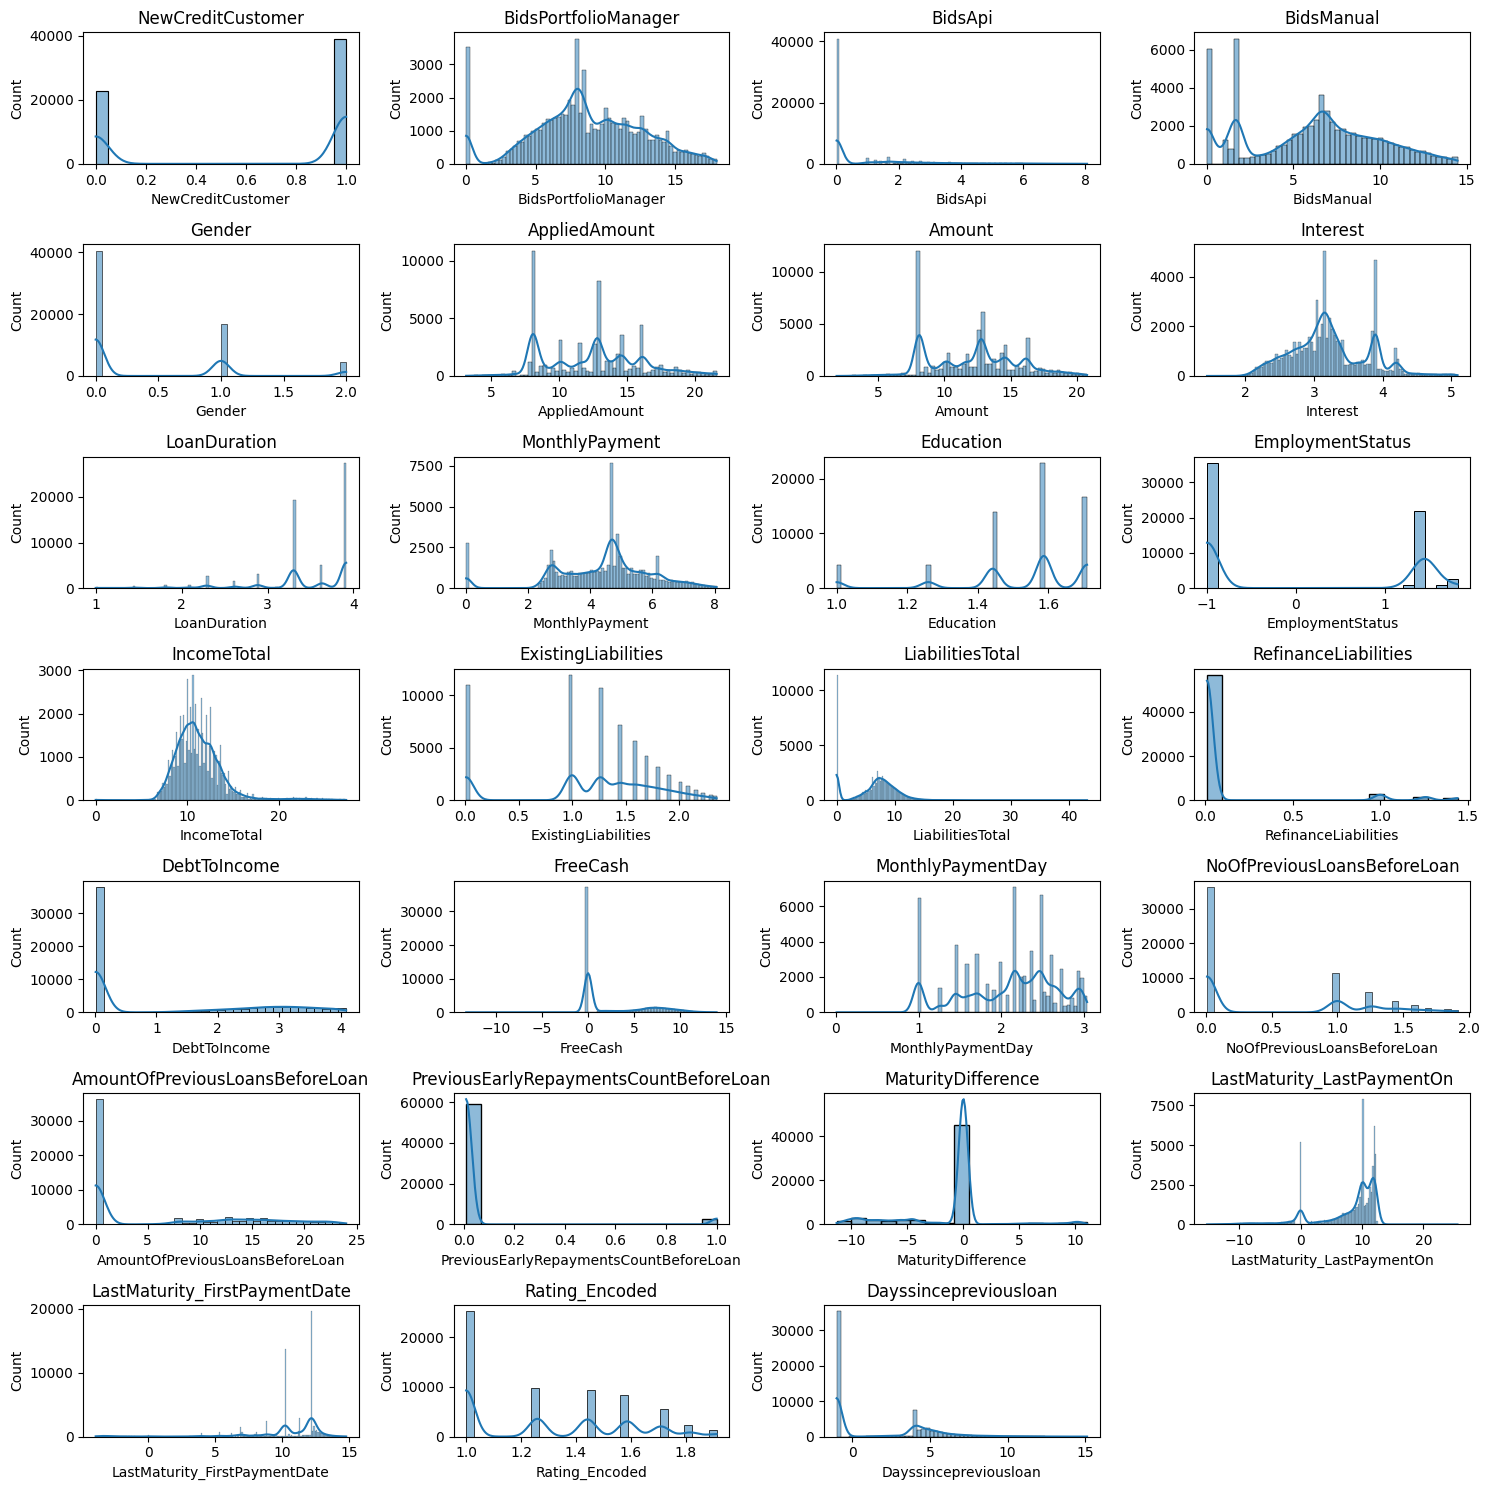

In [38]:
visualize_dis()

In [39]:
X_train.head()

,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,Age,Gender,AppliedAmount,Amount,Interest,...,MonthlyPaymentDay,Restructured,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,MaturityDifference,LastMaturity_LastPaymentOn,LastMaturity_FirstPaymentDate,Rating_Encoded,Dayssincepreviousloan
4100,7.91046,0.01,5.896369,-inline-,1,True,0.0,8.879040,8.879040,3.036589,...,1.912931,False,0.010000,0.010000,0.01,0.01,3.000000,8.015595,1.44225,-1.000000
249,0.01000,0.01,6.836754,-kiisuke-,1,True,1.0,6.836755,6.836758,3.107233,...,1.709976,False,0.010000,0.010000,0.01,0.01,0.010000,6.952053,1.00000,-1.000000
849,0.01000,0.01,6.346681,-kiisuke-,0,True,1.0,6.346681,6.347064,3.361975,...,1.709976,False,1.000000,6.836758,0.01,0.01,6.431228,8.031129,1.00000,6.027650
908,0.01000,0.01,6.183874,-kiisuke-,0,True,1.0,6.183873,6.183380,3.361975,...,1.709976,False,1.259921,8.316730,0.01,0.01,6.686883,8.031129,1.00000,2.466212
11999,0.01000,0.01,10.000000,-party-power-,1,True,0.0,10.000000,10.000000,3.470777,...,2.154435,False,0.010000,0.010000,0.01,0.01,4.904868,6.945150,1.00000,-1.000000


In [40]:
from sklearn.preprocessing import StandardScaler
# Initialize StandardScaler
scaler = StandardScaler()

numeric_features_train_df = X_train.select_dtypes(include=['int64','float64','bool'])

# Fit and transform the training data
X_train[numeric_features] = scaler.fit_transform(numeric_features_train_df).astype(np.float32)

# Transform the testing data using the same scaler
numeric_features_test_df = X_test.select_dtypes(include=['int64','float64','bool'])
X_test[numeric_features] = scaler.transform(numeric_features_test_df).astype(np.float32)

In [41]:
X_train.head()

,BidsPortfolioManager,BidsApi,BidsManual,UserName,NewCreditCustomer,Age,Gender,AppliedAmount,Amount,Interest,...,MonthlyPaymentDay,Restructured,NoOfPreviousLoansBeforeLoan,AmountOfPreviousLoansBeforeLoan,PreviousEarlyRepaymentsCountBeforeLoan,MaturityDifference,LastMaturity_LastPaymentOn,LastMaturity_FirstPaymentDate,Rating_Encoded,Dayssincepreviousloan
4100,-0.197751,-0.588356,-0.065669,-inline-,0.762821,0.020514,-0.669245,-1.027105,-1.002300,-0.341103,...,-0.337109,-0.50184,-0.808412,-0.784721,-0.214383,0.291868,-1.011570,-0.826196,0.489590,-0.809965
249,-2.208464,-0.588356,0.185927,-kiisuke-,0.762821,0.020514,0.934364,-1.596357,-1.613085,-0.213216,...,-0.690920,-0.50184,-0.808412,-0.784721,-0.214383,0.291868,-1.609463,-1.181636,-1.035507,-0.809965
849,-2.208464,-0.588356,0.054810,-kiisuke-,-1.310924,0.020514,0.934364,-1.732957,-1.759537,0.247951,...,-0.690920,-0.50184,0.748068,0.070096,-0.214383,0.291868,-0.325448,-0.821005,-1.035507,1.363681
908,-2.208464,-0.588356,0.011252,-kiisuke-,-1.310924,0.020514,0.934364,-1.778337,-1.808490,0.247951,...,-0.690920,-0.50184,1.156716,0.255412,-0.214383,0.291868,-0.274326,-0.821005,-1.035507,0.262131
11999,-2.208464,-0.588356,1.032239,-party-power-,0.762821,0.020514,-0.669245,-0.714657,-0.667054,0.444917,...,0.083902,-0.50184,-0.808412,-0.784721,-0.214383,0.291868,-0.630665,-1.183943,-1.035507,-0.809965


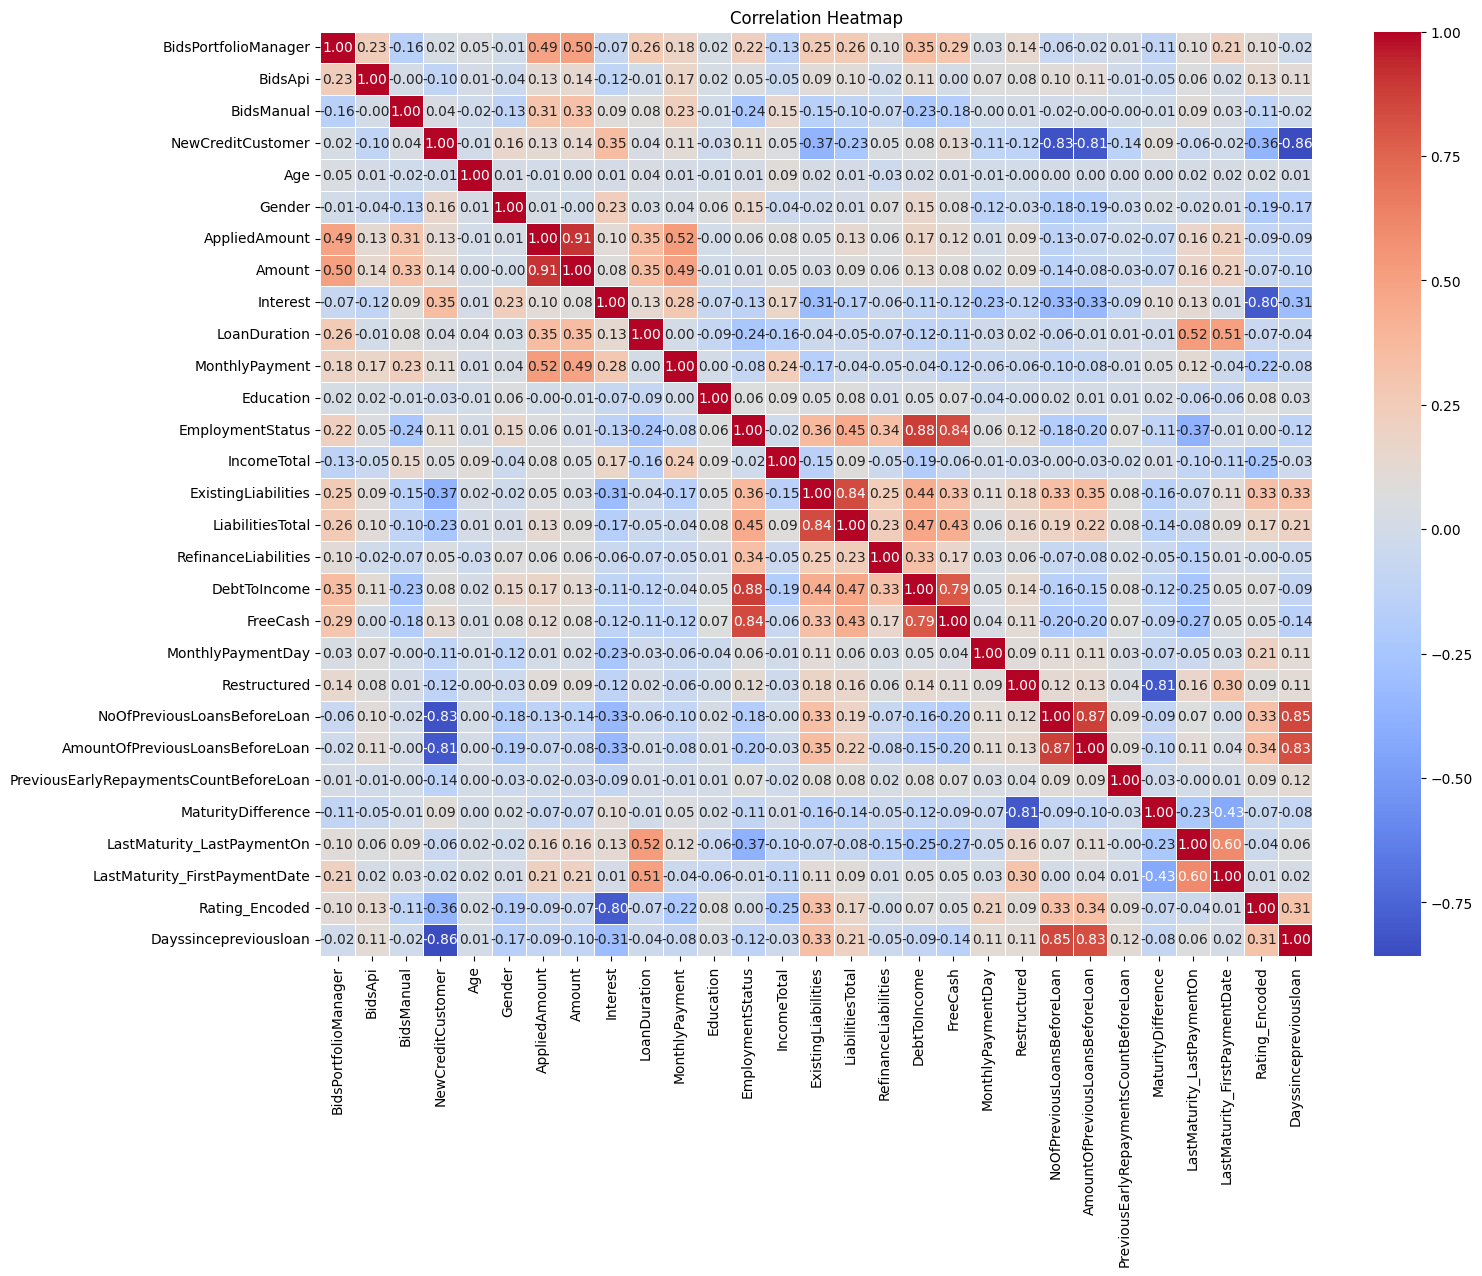

In [42]:
cor_matrix = X_train.drop(columns={'UserName'}).corr()

plt.figure(figsize=(16,12))
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:

# columns_to_remove = ['NewCreditCustomer', 'Interest', 'LoanDuration', 'EmploymentStatus', 'DebtToIncome', 'Restructured', 'LastMaturity_LastPaymentOn']

X_train = X_train.drop(columns=columns_to_remove, errors='ignore')
X_test = X_test.drop(columns=columns_to_remove, errors='ignore')


In [ ]:
X_train.to_csv('/content/drive/MyDrive/Khóa luận tốt nghiệp/Data/X_train.csv',index=False)
y_train.to_csv('/content/drive/MyDrive/Khóa luận tốt nghiệp/Data/y_train.csv',index=False)
X_test.to_csv('/content/drive/MyDrive/Khóa luận tốt nghiệp/Data/X_test.csv',index=False)
y_test.to_csv('/content/drive/MyDrive/Khóa luận tốt nghiệp/Data/y_test.csv',index=False)